# CONFIGURATION

Change parameter here

In [20]:
import os
from datetime import datetime

CONFIG = {
    # ---- DATASET ----
    "train_dataset_dir": "data/processed/structural_defects_50_20_30/",
    "test_dataset_dir": None,  # set different path to test on another dataset

    # ---- SPLIT (only used if dataset not already split) ----
    "auto_split": True,  # True = split data, False = assume already split
    "source_dir": "data/raw/structural_defects",
    "split_ratio": (0.5, 0.2, 0.3),

    # ---- TRAINING ----
    "epochs": 3,
    "batch_size": 16,
    "learning_rate": 0.001,
    "img_size": 224,

    # ---- DATA USAGE ----
    "train_subset": 0.5,   # 1.0 = 100%, 0.75, 0.5, 0.25
    "val_subset": 0.2,
    "test_subset": 0.3,

    # ---- MODEL ----
    "freeze_backbone": False,

    # ---- OUTPUT ----
    "output_dir": "experiments",

    # ---- CHECKPOINT CONTROL ----
    "resume_checkpoint": None,   # path to .pth (resume training)
    "test_checkpoint": None,     # path to .pth (test only)
    "test_only": False,          # True = skip training

    # ---- TENSORBOARD ----
    "use_tensorboard": True,
}

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
SAVE_DIR = os.path.join(CONFIG["output_dir"], RUN_ID)
os.makedirs(SAVE_DIR, exist_ok=True)

print("Run ID:", RUN_ID)

Run ID: 20260425_202241


# IMPORT, DEVICE, TENSORBOARD

In [34]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

from torch.utils.tensorboard import SummaryWriter

writer = None
if CONFIG["use_tensorboard"]:
    log_dir = os.path.join(SAVE_DIR, "logs")
    writer = SummaryWriter(log_dir=log_dir)
    print("TensorBoard logs at:", log_dir)

Using device: cpu
TensorBoard logs at: experiments\20260425_202241\logs


# DATA SPLIT

In [22]:
import shutil
from sklearn.model_selection import train_test_split

def split_dataset(source_dir, dest_dir, ratios):
    train_size, val_size, test_size = ratios

    categories = [d for d in os.listdir(source_dir)
                  if os.path.isdir(os.path.join(source_dir, d))]

    for category in categories:
        category_path = os.path.join(source_dir, category)
        classes = os.listdir(category_path)

        for cls in classes:
            class_path = os.path.join(category_path, cls)
            images = os.listdir(class_path)

            train, temp = train_test_split(images, test_size=(1-train_size), random_state=42)
            val_ratio = val_size / (val_size + test_size)
            val, test = train_test_split(temp, test_size=(1-val_ratio), random_state=42)

            splits = {"train": train, "val": val, "test": test}

            for split_name, files in splits.items():
                dst = os.path.join(dest_dir, split_name, category, cls)
                os.makedirs(dst, exist_ok=True)

                for f in files:
                    shutil.copy(os.path.join(class_path, f),
                                os.path.join(dst, f))

if CONFIG["auto_split"]:
    split_dataset(CONFIG["source_dir"], CONFIG["train_dataset_dir"], CONFIG["split_ratio"])

# DATA TRANSFORM

In [24]:
train_tf = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

test_tf = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
])

# LOAD DATASET and SUBSAMPLING

In [25]:
def load_dataset(path, transform, subset_ratio=1.0):
    dataset = datasets.ImageFolder(path, transform=transform)

    if subset_ratio < 1.0:
        n = int(len(dataset) * subset_ratio)
        indices = np.random.choice(len(dataset), n, replace=False)
        dataset = Subset(dataset, indices)

    return dataset

train_dir = os.path.join(CONFIG["train_dataset_dir"], "train")
val_dir = os.path.join(CONFIG["train_dataset_dir"], "val")

test_base = CONFIG["test_dataset_dir"] or CONFIG["train_dataset_dir"]
test_dir = os.path.join(test_base, "test")

train_ds = load_dataset(train_dir, train_tf, CONFIG["train_subset"])
val_ds = load_dataset(val_dir, test_tf, CONFIG["val_subset"])
test_ds = load_dataset(test_dir, test_tf, CONFIG["test_subset"])

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"])
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"])

classes = train_ds.dataset.classes if isinstance(train_ds, Subset) else train_ds.classes
NUM_CLASSES = len(classes)

print("Classes:", classes)

Classes: ['Decks', 'Pavements', 'Walls']


# LOAD MODEL

In [26]:
model = models.mobilenet_v2(pretrained=True)

if CONFIG["freeze_backbone"]:
    for p in model.features.parameters():
        p.requires_grad = False

model.classifier[1] = nn.Linear(model.last_channel, NUM_CLASSES)
model = model.to(device)

# ---- LOAD CHECKPOINT ----
ckpt_path = None

if CONFIG["test_only"]:
    ckpt_path = CONFIG["test_checkpoint"]
elif CONFIG["resume_checkpoint"]:
    ckpt_path = CONFIG["resume_checkpoint"]

if ckpt_path:
    print("Loading checkpoint:", ckpt_path)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))

if CONFIG["test_only"]:
    assert CONFIG["test_checkpoint"] is not None, "Provide test_checkpoint path!"

# TRAINING SETUP

In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])

# TRAIN LOOP

In [28]:
start_epoch = 0

# If resuming, try to extract epoch number
if CONFIG["resume_checkpoint"]:
    try:
        start_epoch = int(CONFIG["resume_checkpoint"].split("_")[-1].split(".")[0])
    except:
        start_epoch = 0

if not CONFIG["test_only"]:
    for epoch in range(start_epoch, CONFIG["epochs"]):
        model.train()
        train_loss = 0

        for x, y in tqdm(train_loader):
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # ---- VALIDATION ----
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                preds = out.argmax(1)

                correct += (preds == y).sum().item()
                total += y.size(0)

        val_acc = correct / total

        # ---- TENSORBOARD LOGGING ----
        if writer:
            writer.add_scalar("Loss/train", train_loss, epoch)
            writer.add_scalar("Accuracy/val", val_acc, epoch)

        # ---- SAVE CHECKPOINT ----
        ckpt_path = os.path.join(SAVE_DIR, f"epoch_{epoch+1}.pth")
        torch.save(model.state_dict(), ckpt_path)

        print(f"Epoch {epoch+1}: Loss={train_loss:.4f}, ValAcc={val_acc:.4f}")

100%|██████████| 877/877 [12:27<00:00,  1.17it/s]


Epoch 1: Loss=241.2623, ValAcc=0.9679


100%|██████████| 877/877 [11:52<00:00,  1.23it/s]


Epoch 2: Loss=160.5059, ValAcc=0.8489


100%|██████████| 877/877 [11:38<00:00,  1.26it/s]


Epoch 3: Loss=132.7673, ValAcc=0.9608


# TEST

Saved test results to: experiments\20260425_202241\test_results.csv

📊 METRICS
Accuracy : 0.9677
Precision: 0.9691
Recall   : 0.9677
F1-score : 0.9679

📋 Classification Report

              precision    recall  f1-score   support

       Decks       0.92      0.99      0.95      1321
   Pavements       0.98      0.96      0.97      2118
       Walls       0.99      0.96      0.97      1610

    accuracy                           0.97      5049
   macro avg       0.96      0.97      0.97      5049
weighted avg       0.97      0.97      0.97      5049



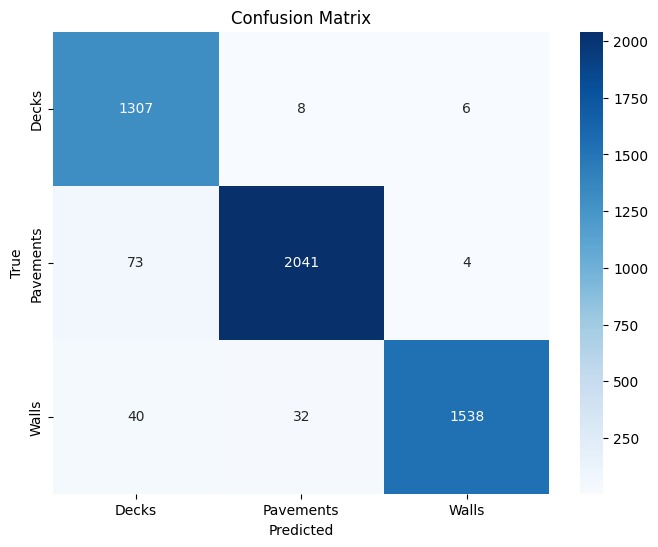

Saved confusion matrix:
- experiments\20260425_202241\confusion_matrix.csv
- experiments\20260425_202241\confusion_matrix.png
Saved metrics to: experiments\20260425_202241\metrics.csv


In [35]:
# -----------------------
# MODEL EVAL
# -----------------------
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)

        out = model(x)
        preds = out.argmax(1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(y.numpy())

# -----------------------
# DATAFRAME RESULTS
# -----------------------
df = pd.DataFrame({
    "true": all_labels,
    "pred": all_preds
})

# safer mapping (avoids crashes if index mismatch)
df["true_label"] = [classes[i] for i in df["true"]]
df["pred_label"] = [classes[i] for i in df["pred"]]

# add config (flatten safely)
for k, v in CONFIG.items():
    df[k] = str(v)

csv_path = os.path.join(SAVE_DIR, "test_results.csv")
df.to_csv(csv_path, index=False)

print("Saved test results to:", csv_path)

# -----------------------
# METRICS
# -----------------------
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

print("\n📊 METRICS")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\n📋 Classification Report\n")
print(classification_report(all_labels, all_preds, target_names=classes, zero_division=0))

# -----------------------
# CONFUSION MATRIX
# -----------------------
cm = confusion_matrix(all_labels, all_preds)

# CSV save
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
cm_csv_path = os.path.join(SAVE_DIR, "confusion_matrix.csv")
cm_df.to_csv(cm_csv_path)

# PNG save
plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

cm_img_path = os.path.join(SAVE_DIR, "confusion_matrix.png")
plt.savefig(cm_img_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved confusion matrix:")
print("-", cm_csv_path)
print("-", cm_img_path)

# -----------------------
# METRICS CSV
# -----------------------
metrics_df = pd.DataFrame([{
    "run_id": RUN_ID,
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    **CONFIG
}])

metrics_path = os.path.join(SAVE_DIR, "metrics.csv")
metrics_df.to_csv(metrics_path, index=False)

print("Saved metrics to:", metrics_path)

# -----------------------
# TENSORBOARD LOGGING
# -----------------------
if writer:
    writer.add_scalar("Test/Accuracy", accuracy)
    writer.add_scalar("Test/Precision", precision)
    writer.add_scalar("Test/Recall", recall)
    writer.add_scalar("Test/F1", f1)

    # log confusion matrix as figure
    fig = plt.figure(figsize=(6,5))
    sns.heatmap(cm_df, annot=False, cmap="Blues")
    writer.add_figure("Confusion_Matrix", fig)

# IMPORTANT: DO NOT close writer here (do it once at end of notebook)

# SUMMARY CSV

In [36]:
# -----------------------
# BUILD SUMMARY ROW
# -----------------------
summary = {
    "run_id": RUN_ID,
    "num_classes": NUM_CLASSES,

    # ---- METRICS (must exist from test step) ----
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),

    # ---- CONFIG ----
    **CONFIG
}

summary_path = os.path.join(CONFIG["output_dir"], "summary.csv")

# -----------------------
# APPEND SAFELY
# -----------------------
if os.path.exists(summary_path):
    df_old = pd.read_csv(summary_path)

    df_new = pd.concat(
        [df_old, pd.DataFrame([summary])],
        ignore_index=True
    )
else:
    df_new = pd.DataFrame([summary])

df_new.to_csv(summary_path, index=False)

print("✅ Updated summary.csv at:", summary_path)

✅ Updated summary.csv at: experiments\summary.csv
